Install the Libraries Required

In [1]:
%pip install requests numpy matplotlib scipy scikit-learn torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
import numpy as np
import requests

Helper Functions to Read Fiels

In [ ]:
def readBiopacResults(filename):
    with open(filename, 'r') as f:
        temp = [l for l in f]
    result = []
    for i in range(0, len(temp)):
        q = temp[i].strip().split()
        if q:
            result.append([float(v) for v in q])

    return np.array(result)

In [ ]:
def readCSV(filename):
    """
    Read a CSV file (with a single header row) into a numeric NumPy array.

    Expected format
    - First line: column headers (skipped)
    - Remaining lines: comma-separated numeric values per row

    Returns
    - np.ndarray of shape (num_rows, num_columns)
    """
    with open(filename, 'r') as f:
        temp = [l for l in f]

    result = []
    for i in range(0, len(temp)):
        # Skip header row
        if i == 0:
            continue
        q = temp[i].strip().split(',')
        if q:
            result.append([float(val) for val in q])

    return np.array(result)

Load a public data set with ECG data

In [25]:
# Download a public ECG sample and load it as our working dataset
# - Source: NeuroKit demo ECG sampled at 1000 Hz
# - We save it locally as CSV and then parse it into a numeric array
# - Variable `fs` holds the sampling rate (Hz); downstream code relies on it

url = 'https://raw.githubusercontent.com/neuropsychology/NeuroKit/master/data/ecg_1000hz.csv'
local_filename = 'sample_ecg_data.csv'
fs = 1000  # samples per second (Hz)

# Fetch and store the CSV file
response = requests.get(url)
with open(local_filename, 'wb') as f:
    f.write(response.content)

# Load the CSV as a numeric array (skips header, parses comma-separated values)
try:
    data = readCSV(local_filename)
    print(f'Data Shape: {data.shape}')
except Exception as e:
    print(f'Error reading file: {e}')

Data Shape: (50000, 1)


Pre-Process EEG data

In [ ]:
def bandpass_filter(data, lowcut, highcut, fs, order=5):
    """
    Apply a zero-phase band-pass filter to emphasize the QRS energy band.

    Parameters
    - data: 1D array of ECG samples
    - lowcut/highcut: passband edges in Hz (typical QRS band ~5–15 Hz)
    - fs: sampling rate in Hz
    - order: Butterworth filter order

    Notes
    - Uses filtfilt (zero-phase). filtfilt requires a minimum input length (padlen).
      If the input is too short, we skip filtering to avoid runtime errors and
      simply return the unfiltered data.
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')

    # filtfilt requires len(x) > padlen = 3*(max(len(a), len(b)) - 1)
    padlen = 3 * (max(len(a), len(b)) - 1)
    if data.size <= padlen:
        return data

    y = filtfilt(b, a, data)
    return y


def preprocess_data(raw_data, fs):
    """
    Standardize an ECG channel for analysis.

    Steps
    1) Ensure a 1D float array (select first column if multi-channel)
    2) Band-pass filter to emphasize the QRS complex (default ~5–15 Hz)
    3) Z-score normalization: center at 0, unit variance (guarding zero std)

    Returns
    - 1D NumPy array (float) normalized and ready for peak detection or modeling
    """
    # 1) Ensure 1D float array
    x = np.asarray(raw_data)
    if x.ndim > 1:
        x = x[:, 0]
    x = x.astype(float)

    # 2) Band-pass filter around the QRS band
    lowcut = 5
    highcut = 15.0
    filtered = bandpass_filter(x, lowcut, highcut, fs, order=2)

    # 3) Z-score normalization with a zero-std safeguard
    std = np.std(filtered)
    normalized = (filtered - np.mean(filtered)) / std
    return normalized

Plot a result

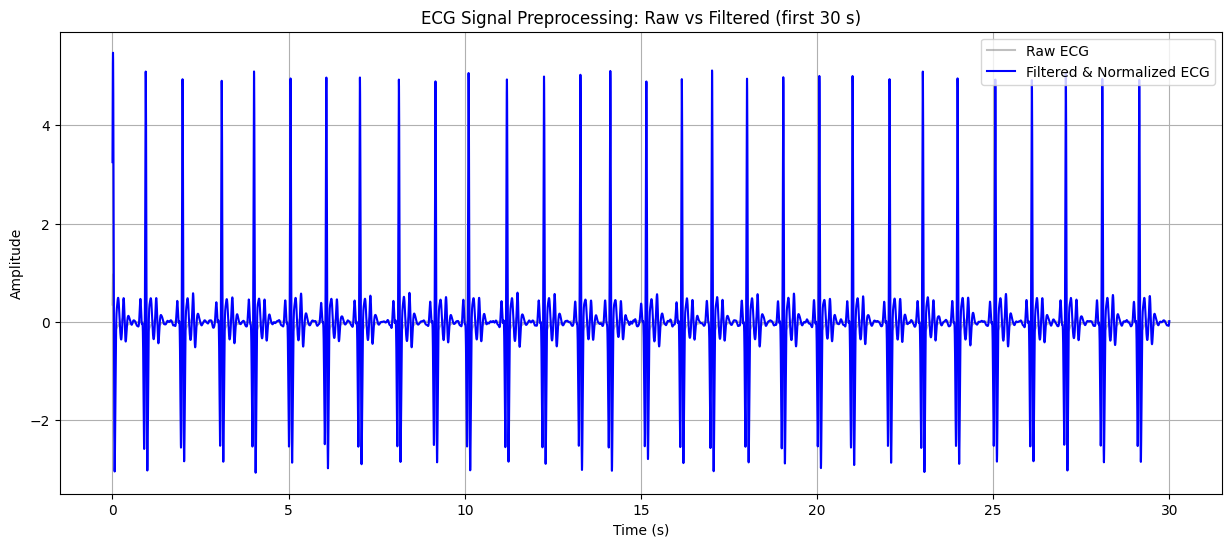

Preprocessing complete: Band-pass (5–15 Hz) and Z-score normalization applied.


In [7]:
# Visual check: compare raw ECG vs. preprocessed ECG
# - Gray trace: unfiltered raw signal
# - Blue trace: band‑passed and z‑scored signal used for detection
# - We limit the view to `time_toDisplay` seconds for readability

ecg_raw = data[:, 0]
ecg_normalized = preprocess_data(ecg_raw, fs)

time = np.arange(len(ecg_raw)) / fs
time_toDisplay = 30  # seconds to plot

plt.figure(figsize=(15, 6))
plt.plot(time[: time_toDisplay * fs], ecg_raw[: time_toDisplay * fs],
         label='Raw ECG', alpha=0.5, color='gray')
plt.plot(time[: time_toDisplay * fs], ecg_normalized[: time_toDisplay * fs],
         label='Filtered & Normalized ECG', color='blue')
plt.title('ECG Signal Preprocessing: Raw vs Filtered (first 30 s)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

print('Preprocessing complete: Band-pass (5–15 Hz) and Z-score normalization applied.')

Label the Data set

In [8]:
# Peak-only labeling (Ground Truth Creation)
# --------------------------------------------------------------
# Goal: Mark the locations of R-peaks (heartbeats) directly on the
# normalized ECG signal, without building a separate windowed dataset.
#
# How it works
# - We look for local maxima that are separated by at least `min_rr_sec`
#   seconds (physiological refractory period) so we avoid double-counting
#   the same beat.
# - We enforce a minimum peak height (`height_thr`) on the normalized
#   signal to reduce spurious detections.
# - We then create a label vector (`y`) the same length as the ECG, where
#   y[i] == 1 indicates a detected peak at sample i and 0 otherwise.
#
# Outputs
# - `X`: the normalized ECG signal (1D array)
# - `y`: the binary per-sample label vector (1D array)

min_rr_sec = 0.6  # minimum RR interval to avoid double counting (seconds)
height_thr = 1.5  # minimum peak height on the normalized signal (z-scored)

# Detect peaks on the normalized signal
distance_samples = int(min_rr_sec * fs)
peaks, _ = find_peaks(ecg_normalized, distance=distance_samples, height=height_thr)

# Create a binary label vector aligned with the full signal
labels_vector = np.zeros(ecg_normalized.shape[0], dtype=int)
labels_vector[peaks] = 1

# Feature (X) and label (y) for downstream use
X = ecg_normalized
y = labels_vector

Display Training label tests

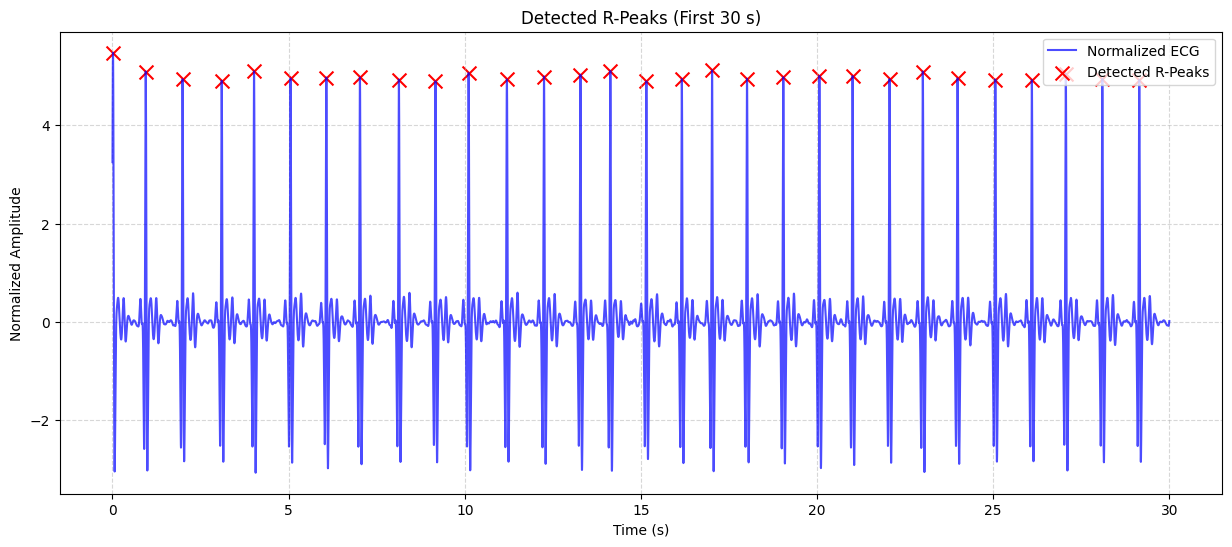

Visualization of the first 30 seconds complete.


In [9]:
# Visualize detected peaks on the normalized ECG (sanity check)
# ----------------------------------------------------------------
# This plot helps confirm that the automatic peak detector is finding
# reasonable R-peaks at the right times. We display only the first
# `duration` seconds for clarity.

# 1) Choose how many seconds to show
duration = 30
max_index = duration * fs

# 2) Slice the ECG and corresponding time axis
# (Both arrays are aligned: time[i] is the timestamp for sample i)
time_segment = time[:max_index]
signal_segment = ecg_normalized[:max_index]

# 3) Keep only ground-truth peaks that fall within the displayed window
filtered_gt_peaks = peaks[peaks < max_index]

# 4) Plot ECG and overlay detected peaks
plt.figure(figsize=(15, 6))
plt.plot(time_segment, signal_segment, label='Normalized ECG', color='blue', alpha=0.7)
plt.scatter(time[filtered_gt_peaks], ecg_normalized[filtered_gt_peaks],
            color='red', marker='x', s=100, label='Detected R-Peaks')

# 5) Labels and cosmetics
plt.xlabel('Time (s)')
plt.ylabel('Normalized Amplitude')
plt.title('Detected R-Peaks (First 30 s)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f'Visualization of the first {duration} seconds complete.')

Verified Training labelling is good, train 1D CNN model.

In [10]:
# Sequence labeling model (1D CNN) for per-sample QRS detection
# ----------------------------------------------------------------
# Objective
# Train a simple convolutional network that takes the entire ECG segment and
# predicts, for each sample, whether it belongs to an R-peak (1) or not (0).
#
# Design choices
# - Train/validation split is performed by time (80/20) to respect temporal order.
# - Convolution-only (no pooling) to preserve length: output logits per sample.
# - Class imbalance is handled with `pos_weight` in BCEWithLogitsLoss.
# - Metrics: per-sample accuracy for train/val; we later derive peak-level metrics
#   by peak-picking the model probabilities.
#
# Usage
# - Ensure `X` (normalized ECG) and `y` (binary labels) are prepared upstream.
# - Run this cell to train; subsequent cells evaluate per-sample and peak metrics.

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import accuracy_score

# 1) Train/Val split by time (80/20)
T = X.shape[0]
split_idx = int(0.8 * T)
X_train_np, y_train_np = X[:split_idx], y[:split_idx]
X_val_np,   y_val_np   = X[split_idx:], y[split_idx:]

# 2) Convert to tensors with explicit (B, C, T) shapes
X_train_t = torch.tensor(X_train_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
y_train_t = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
X_val_t   = torch.tensor(X_val_np,   dtype=torch.float32).unsqueeze(0).unsqueeze(0)
y_val_t   = torch.tensor(y_val_np,   dtype=torch.float32).unsqueeze(0).unsqueeze(0)

# 3) Handle class imbalance (peaks are rare compared to non-peaks)
pos = float(y_train_np.sum())
neg = float(len(y_train_np) - pos)
pos_weight = torch.tensor([neg / pos], dtype=torch.float32) if pos > 0 else None

class ECGSequenceCNN(nn.Module):
    """A compact 1D CNN for per-sample QRS detection.

    Architecture
    - Two standard conv layers to learn local waveform features
    - One dilated conv to expand receptive field without pooling
    - Final 1x1 conv to produce a per-sample logit (no length change)
    """
    def __init__(self):
        super().__init__()
        def same_pad(k, d=1):
            return int((d * (k - 1)) // 2)
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=same_pad(7)), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=7, padding=same_pad(7)), nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=7, dilation=2, padding=same_pad(7, d=2)), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Conv1d(64, 1, kernel_size=1)  # logits per time sample
        )
    def forward(self, x):  # x: (B,1,T)
        return self.net(x)  # (B,1,T)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = ECGSequenceCNN().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device) if pos_weight is not None else None)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 4) Training loop (full sequence per batch)
train_acc_history, val_acc_history = [], []
train_loss_history, val_loss_history = [], []
epochs = 125

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    logits_train = model(X_train_t.to(device))  # (1,1,T_train)
    loss = criterion(logits_train, y_train_t.to(device))
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        preds_train = (logits_train.sigmoid() >= 0.5).cpu().numpy().astype(int).reshape(-1)
        train_acc = accuracy_score(y_train_np, preds_train)

    model.eval()
    with torch.no_grad():
        logits_val = model(X_val_t.to(device))
        val_loss = criterion(logits_val, y_val_t.to(device)).item()
        preds_val = (logits_val.sigmoid() >= 0.5).cpu().numpy().astype(int).reshape(-1)
        val_acc = accuracy_score(y_val_np, preds_val)

    train_loss_history.append(loss.item())
    val_loss_history.append(val_loss)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(f'Epoch {epoch+1:02d}/{epochs} — loss: {loss.item():.4f}  acc: {train_acc:.4f}  val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}')

# 5) Final accuracy on the validation timeline (per-sample)
y_pred = preds_val  # carried forward for evaluation cell
print(f'\nSequence labeling — Validation Accuracy: {val_acc:.4f} (per-sample)')

Using device: cpu
Epoch 01/125 — loss: 1.3770  acc: 0.0441  val_loss: 1.0972  val_acc: 0.1978
Epoch 02/125 — loss: 1.0898  acc: 0.1935  val_loss: 0.9198  val_acc: 0.4313
Epoch 03/125 — loss: 0.9237  acc: 0.4367  val_loss: 0.8175  val_acc: 0.7183
Epoch 04/125 — loss: 0.8103  acc: 0.7158  val_loss: 0.7389  val_acc: 0.7916
Epoch 05/125 — loss: 0.7392  acc: 0.7883  val_loss: 0.6788  val_acc: 0.8246
Epoch 06/125 — loss: 0.6810  acc: 0.8217  val_loss: 0.6235  val_acc: 0.8704
Epoch 07/125 — loss: 0.6264  acc: 0.8649  val_loss: 0.5670  val_acc: 0.9408
Epoch 08/125 — loss: 0.5681  acc: 0.9319  val_loss: 0.5075  val_acc: 0.9600
Epoch 09/125 — loss: 0.5173  acc: 0.9588  val_loss: 0.4510  val_acc: 0.9620
Epoch 10/125 — loss: 0.4541  acc: 0.9620  val_loss: 0.3975  val_acc: 0.9637
Epoch 11/125 — loss: 0.4024  acc: 0.9636  val_loss: 0.3410  val_acc: 0.9640
Epoch 12/125 — loss: 0.3497  acc: 0.9640  val_loss: 0.2935  val_acc: 0.9642
Epoch 13/125 — loss: 0.3049  acc: 0.9643  val_loss: 0.2540  val_acc: 0

Test Model on validation dataset.

--- Per-sample Confusion Matrix ---
[[9882  108]
 [   0   10]]

--- Per-sample Classification Report ---
              precision    recall  f1-score   support

 Non-Complex       1.00      0.99      0.99      9990
     Complex       0.08      1.00      0.16        10

    accuracy                           0.99     10000
   macro avg       0.54      0.99      0.58     10000
weighted avg       1.00      0.99      0.99     10000



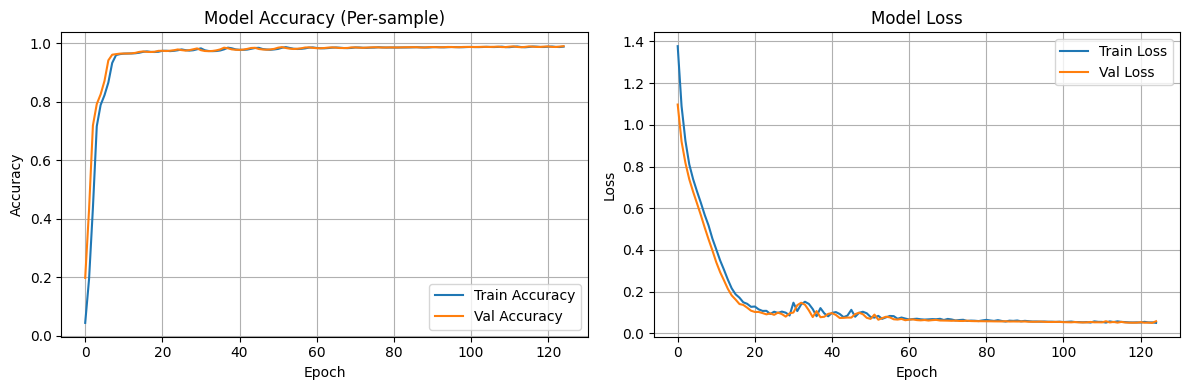


--- Detection-level Summary (Validation Segment) ---
Predicted peaks: 10  |  TP: 10  |  FP: 0  |  FN: 0  |  tol=50 samples
Precision: 1.0000  Recall: 1.0000  F1: 1.0000


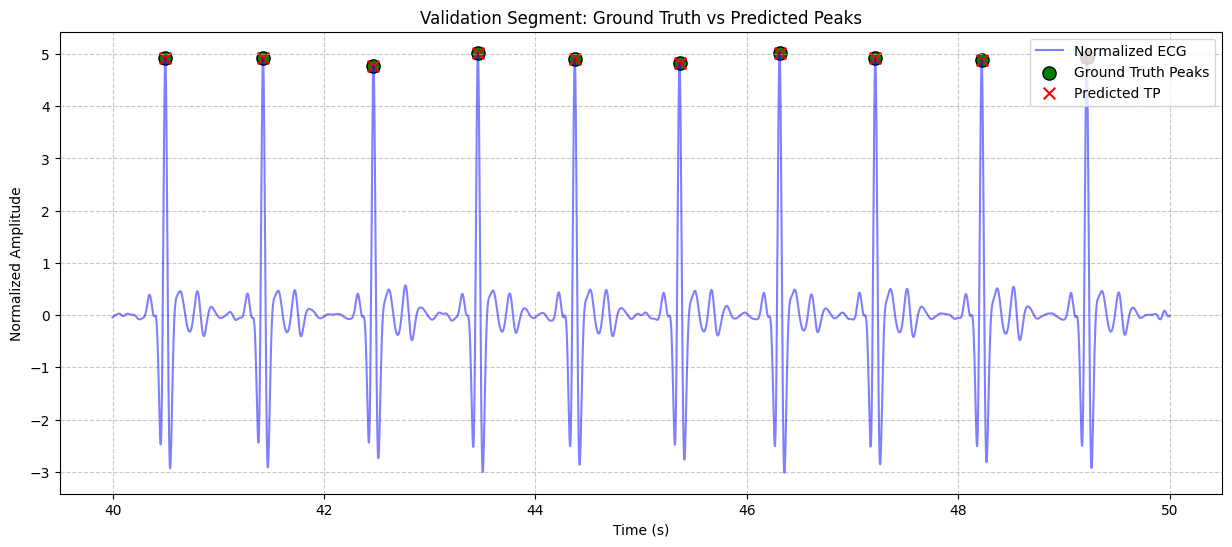

In [11]:
# Validation and Visualization
# ---------------------------
# This cell reports how well the sequence model performs in two ways:
# 1) Per-sample metrics (confusion matrix, precision/recall for labels y)
# 2) Detection-level metrics: we convert model probabilities to peak picks
#    and compare predicted peaks to ground-truth peaks over a time segment.

from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
import matplotlib.pyplot as plt
import numpy as np

# 1) Per-sample validation (sequence labeling)
cm = confusion_matrix(y_val_np, y_pred)
tn, fp, fn, tp = cm.ravel()
print("--- Per-sample Confusion Matrix ---")
print(cm)
print("\n--- Per-sample Classification Report ---")
print(classification_report(y_val_np, y_pred, target_names=['Non-Complex', 'Complex']))

# 2) Plot training curves for quick diagnostics
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_acc_history, label='Train Accuracy')
plt.plot(val_acc_history,   label='Val Accuracy')
plt.title('Model Accuracy (Per-sample)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history,   label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

# 3) Detection-level evaluation on the validation timeline
#    Convert model probabilities to predicted peaks and compare to GT peaks.
from scipy.signal import find_peaks

# Recompute validation probabilities (per-sample)
model.eval()
with torch.no_grad():
    proba_val = model(X_val_t.to(device)).sigmoid().cpu().numpy().reshape(-1)

# Map validation indices into absolute timeline
# so we can align with the original `time` and `y` arrays.
total_T = len(X)
split_idx = int(0.8 * total_T)
val_abs_start = split_idx
val_abs_end   = total_T

# Select a segment to visualize: last 30 seconds of validation (or shorter if needed)
plot_len = min(30 * fs, val_abs_end - val_abs_start)
seg_start_abs = val_abs_end - plot_len
seg_end_abs   = val_abs_end

time_seg   = time[seg_start_abs:seg_end_abs]
signal_seg = ecg_normalized[seg_start_abs:seg_end_abs]

# Ground-truth peaks in the segment
true_peaks_abs = np.where(y == 1)[0]
true_peaks_seg = true_peaks_abs[(true_peaks_abs >= seg_start_abs) & (true_peaks_abs < seg_end_abs)]

# Predicted peaks from probabilities in the same segment
proba_seg = proba_val[(seg_start_abs - val_abs_start):(seg_end_abs - val_abs_start)]

# Peak picking on probabilities: enforce a minimum RR interval and a probability threshold
min_rr_sec = 0.6
distance_samples = int(min_rr_sec * fs)
height_thr = 0.5  # probability threshold; adjust to trade off recall vs precision
pred_peaks_rel, _ = find_peaks(proba_seg, distance=distance_samples, height=height_thr)
pred_peaks_abs = pred_peaks_rel + seg_start_abs

# Match predictions to GT with a small time tolerance (±5% of 1s)
tol = max(1, int(0.05 * fs))

def match_predictions(pred_indices, gt_indices, tol):
    """Greedy one-to-one matching within `tol` samples to compute TP/FP."""
    tp, fp = [], []
    used = np.zeros(len(gt_indices), dtype=bool)
    for p in pred_indices:
        diffs = np.abs(gt_indices - p)
        if len(diffs) and diffs.min() <= tol:
            j = diffs.argmin()
            if not used[j]:
                tp.append(p); used[j] = True
            else:
                fp.append(p)
        else:
            fp.append(p)
    return np.array(tp, dtype=int), np.array(fp, dtype=int)

tp_peaks_abs, fp_peaks_abs = match_predictions(pred_peaks_abs, true_peaks_seg, tol)
fn_count = max(0, len(true_peaks_seg) - len(tp_peaks_abs))

# Detection-level summary
prec, rec, f1, _ = precision_recall_fscore_support(
    [1]*len(tp_peaks_abs) + [1]*fn_count + [0]*len(fp_peaks_abs),
    [1]*len(tp_peaks_abs) + [0]*fn_count + [1]*len(fp_peaks_abs),
    average='binary', zero_division=0
)
print("\n--- Detection-level Summary (Validation Segment) ---")
print(f"Predicted peaks: {len(pred_peaks_abs)}  |  TP: {len(tp_peaks_abs)}  |  FP: {len(fp_peaks_abs)}  |  FN: {fn_count}  |  tol={tol} samples")
print(f"Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")

# 4) Plot GT vs predicted peaks on the chosen validation segment
plt.figure(figsize=(15, 6))
plt.plot(time_seg, signal_seg, label='Normalized ECG', color='blue', alpha=0.5)
plt.scatter(time[true_peaks_seg], ecg_normalized[true_peaks_seg],
            color='green', marker='o', s=90, label='Ground Truth Peaks', edgecolors='black')
if len(tp_peaks_abs):
    plt.scatter(time[tp_peaks_abs], ecg_normalized[tp_peaks_abs],
                color='red', marker='x', s=70, label='Predicted TP')
if len(fp_peaks_abs):
    plt.scatter(time[fp_peaks_abs], ecg_normalized[fp_peaks_abs],
                color='orange', marker='^', s=80, label='Predicted FP', edgecolors='black')
plt.title('Validation Segment: Ground Truth vs Predicted Peaks')
plt.xlabel('Time (s)')
plt.ylabel('Normalized Amplitude')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Define Method to lerage trained model on new data

In [12]:
def predict_complexes(raw_data_array, sampling_rate, min_rr_sec=0.6, height_thr=1.5, prominence=None, distance=None):
    """
    Detect R-peaks (heartbeats) from a raw ECG signal by:
    1) Preprocessing (band-pass filtering and z-scoring), then
    2) Running a robust local-peak finder with physiological constraints.

    Parameters
    - raw_data_array (1D array): The ECG samples to analyze.
    - sampling_rate (int): Sampling frequency in Hz (e.g., 800 or 1000).
    - min_rr_sec (float): Minimum time in seconds between peaks to avoid
      double-counting the same heartbeat (default 0.6 s).
    - height_thr (float): Minimum peak height on the normalized signal.
      Since the signal is z-scored, 1.5 corresponds to 1.5 standard deviations
      above the mean (adjust this for noisy data).
    - prominence (float | None): Optional additional constraint to require
      peaks to stand out relative to their neighbors (see scipy.signal.find_peaks).
    - distance (int | None): Minimum distance between peaks in samples. If None,
      we compute it from `min_rr_sec * sampling_rate`.

    Returns
    - np.ndarray: Indices (integer sample positions) of detected R-peaks within
      the original `raw_data_array` index space.

    Examples
    - peaks = predict_complexes(segment, 1000)
    - peaks = predict_complexes(segment, 800, min_rr_sec=0.5, height_thr=2.0)
    """
    # 1) Preprocess to match labeling pipeline (band-pass + z-score)
    sig = preprocess_data(raw_data_array, sampling_rate)

    # 2) Configure peak detection parameters
    if distance is None:
        distance = int(min_rr_sec * sampling_rate)

    peak_kwargs = dict(distance=distance)
    if height_thr is not None:
        peak_kwargs['height'] = height_thr
    if prominence is not None:
        peak_kwargs['prominence'] = prominence

    # 3) Detect local maxima that meet the constraints
    peaks_idx, _ = find_peaks(sig, **peak_kwargs)
    return peaks_idx

Call the model prediction interface

In [22]:
lab3_Results = readBiopacResults('./Lab-03-L05_ayesha.txt')
sample_rate = 800
lab3_results_size = lab3_Results.shape[0] / sample_rate
lab3_Results=lab3_Results[:, 0]
print(f'Duration (s): {lab3_results_size:.2f}')

detected_indices = predict_complexes(lab3_Results, sample_rate)

print('Test completed.')
print(f'Detected {len(detected_indices)} peaks in the test segment.')
if len(detected_indices) > 0:
    print(f'First 10 detected indices: {detected_indices[:10]}')

Duration (s): 163.70
Test completed.
Detected 179 peaks in the test segment.
First 10 detected indices: [ 411 1148 1924 2708 3462 4243 5055 5831 6595 7385]


Plot the output

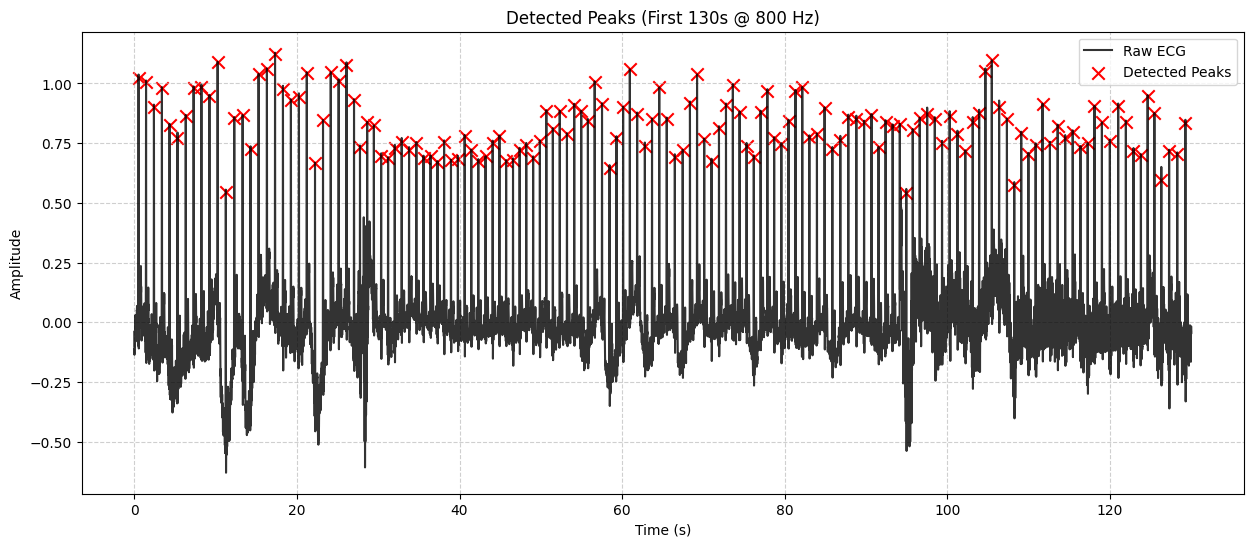

Visualization complete for first 130 seconds at 800 Hz (n=104000).


In [23]:
duration_sec = 130
n = min(int(duration_sec * sample_rate), len(lab3_Results))

# 3) Build time and signal slices
time_segment = np.arange(n) / sample_rate
signal_segment = lab3_Results[:n]

# 4) Filter detected indices to the displayed window
if 'detected_indices' in globals() and detected_indices is not None:
    filtered_detections = detected_indices[(detected_indices >= 0) & (detected_indices < n)]
else:
    filtered_detections = np.array([], dtype=int)

# 5) Plot
plt.figure(figsize=(15, 6))
plt.plot(time_segment, signal_segment, label='Raw ECG', color='black', alpha=0.8)

# Overlay detected complexes with red markers if any
if filtered_detections.size > 0:
    plt.scatter(time_segment[filtered_detections], signal_segment[filtered_detections],
                color='red', marker='x', s=80, label='Detected Peaks')

# Decorate
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'Detected Peaks (First {duration_sec}s @ {sample_rate} Hz)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f'Visualization complete for first {duration_sec} seconds at {sample_rate} Hz (n={n}).')